In [23]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Clustering

In [ ]:
df = pd.read_csv('../data/cleaned_data/merged_machine_data.csv')

In [3]:
df.head()

,Source,Air_Temperature,Process_Temp,Rotational_Speed,Torque,Life_Consumed,Stress_Index,RUL,Is_Failure,Health_Status
0,AI4I,299.228419,306.899157,1559.219588,43.187703,0,0.470538,50,0,Warning
1,AI4I,296.759079,307.729191,1405.990381,46.889688,3,0.505412,49,0,Warning
2,AI4I,298.018549,309.175868,1509.324445,49.237010,5,0.512735,48,0,Warning
3,AI4I,299.183173,308.553352,1425.993973,39.545599,7,0.478745,47,0,Warning
4,AI4I,300.709087,308.954130,1400.229355,40.097456,9,0.485819,46,0,Warning


### PCA

In [7]:
sensor_cols = ['Air_Temperature', 'Process_Temp', 
               'Rotational_Speed', 'Torque', 'Life_Consumed']

In [8]:
X_sensors = df[sensor_cols]

In [16]:
# scaling the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sensors)

In [20]:
pca = PCA(n_components=3) 
X_pca = pca.fit_transform(X_scaled)

In [18]:
print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.64850661 0.20011111 0.14949214]


In [19]:
print("Total explained variance:", np.sum(pca.explained_variance_ratio_))

Total explained variance: 0.9981098520091363


In [21]:
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]
df['PC3'] = X_pca[:, 2]

## KNN clustering

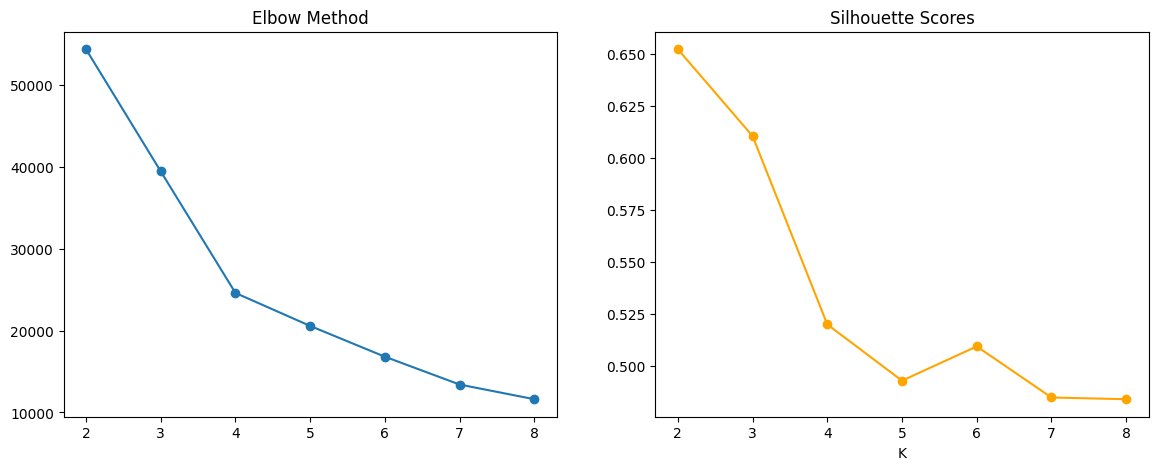

In [25]:
inertias = []
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_pca)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, cluster_labels))

# plot 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(K_range, inertias, marker='o')
ax1.set_title('Elbow Method')

ax2.plot(K_range, silhouette_scores, marker='o', color='orange')
ax2.set_title('Silhouette Scores'); ax2.set_xlabel('K')
#plt.savefig('../results/pca_clustering_evaluation.png')
plt.show()

In [26]:
best_k = 3  # update based on your plot

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(X_pca)

# Check how clusters align with known failure data
print(df.groupby('Cluster')['Is_Failure'].mean())
print(df.groupby('Cluster')['Health_Status'].value_counts())

Cluster
0    0.348312
1    0.213417
2    0.362738
Name: Is_Failure, dtype: float64
Cluster  Health_Status
0        Warning           2411
         Critical          1651
         Healthy            678
1        Warning          16228
         Critical          4403
2        Warning           2621
         Critical          1908
         Healthy            731
Name: count, dtype: int64


In [28]:
# After inspecting the groupby output, map manually
cluster_map = {1: 'Normal', 0: 'Degraded', 2: 'Critical'}
df['Health_Regime'] = df['Cluster'].map(cluster_map)

In [30]:
# Save
df.to_csv("../data/cleaned_data/clustered.csv", index=False)
print(df['Health_Regime'].value_counts())

Health_Regime
Normal      20631
Critical     5260
Degraded     4740
Name: count, dtype: int64
